In [1]:
import os 
import sys
print(os.getcwd())
# os.chdir("../code/SPID_code")

print(os.getcwd())

root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
print(root)
sys.path.insert(0, os.path.join(root, "gym-pybullet-drones"))


c:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\GGSpeciale\code\SPID_code
c:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\GGSpeciale\code\SPID_code
c:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition


In [2]:
import socket

print("Host:", socket.gethostname())
print("SLURM job:", os.environ.get("SLURM_JOB_ID"))

Host: LAPTOP-OMLQD0UR
SLURM job: None


# Load packages

In [3]:
from gmDAGGER import train_spid
from PySRWrapper import PySRPolicy
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

import warnings

from stable_baselines3 import PPO
from gym_pybullet_drones.envs.HoverAviary import HoverAviary
from gym_pybullet_drones.utils.enums import ObservationType, ActionType
import gymnasium as gym
import numpy as np

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\gym-pybullet-drones\gym_pybullet_drones\envs\BaseAviary.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
pybullet build time: Oct 21 2025 12:15:52


# Distill teacher PPO model

In [4]:

warnings.filterwarnings(
    "ignore",
    message="You are trying to run PPO on the GPU"
)

warnings.filterwarnings(
    "ignore",
    message="Note: it looks like you are running in Jupyter"
)

# example

# rewards, best_policy, wrapper, run_dir = train_spid(r"/home/ashc/GGSpeciale/ashc_repo/GGSpeciale/code/baseline_code/baseline_models/cartpole/PPO_cartpole.zip", PPO, "", "CartPole-v1", n_iter=1, total_timesteps=3, verbose=2)

teacher_model_path = r"C:/Users/sofel/OneDrive/Skrivebord/Speciale/safety_addition/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip"
teacher_model = PPO
environment = HoverAviary # ContinuousCartPoleEnv #"Swimmer-v5" # or use string like CartPole-v1

DEFAULT_OBS = ObservationType('kin') # 'kin' or 'rgb'
DEFAULT_ACT = ActionType('one_d_rpm') # 'rpm' or 'pid' or 'vel' or 'one_d_rpm' or 'one_d_pid'

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

environment = lambda: HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=False
    )
)

rewards, best_policy, wrapper, run_dir = train_spid(teacher_path = teacher_model_path, 
                                                    teacher_model = teacher_model, 
                                                    save_folder_path=r"C:/Users/sofel/OneDrive/Skrivebord/Speciale/safety_addition/GGSpeciale/quadcopter-suite/distil/safety_test", 
                                                    save_results=True, 
                                                    environment=environment, 
                                                    n_iter=10, 
                                                    total_timesteps=20*1000, 
                                                    n_eval_episodes=10,
                                                    verbose=2)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Loaded local teacher from: C:/Users/sofel/OneDrive/Skrivebord/Speciale/safety_addition/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip
finished collecting trajectories
computing advantages
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
training
Evaluating trained model
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_

c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Iteration 0: student reward = 333.8626 +/- 0.0000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:/Users/sofel/OneDrive/Skrivebord/Speciale/safety_addition/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip


...

Evaluating trained model
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Iteration 9: student reward = 333.8626 +/- 0.0000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:/Users/sofel/OneDrive/Skrivebord/Speciale/safety_addition/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip


c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
SPID iteration complete. Dataset size: 3
Best policy iteration: 8
Best student reward during search: 470.8897
Teacher eval: 474.1320 +/- 0.0000
Student eval: 470.8890 +/- 0.0008
Saved results to: C:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\GGSpeciale\quadcopter-suite\distil\safety_test


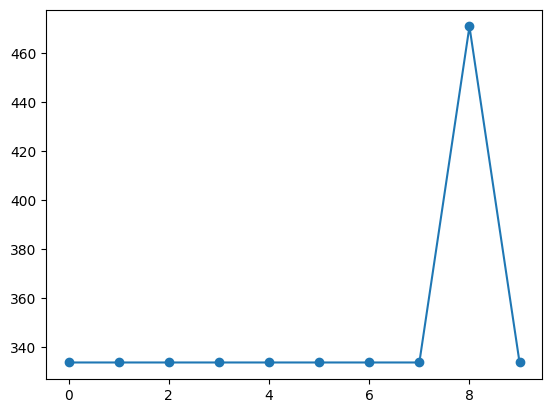

In [5]:
import matplotlib.pyplot as plt

plt.plot(range(len(rewards)), rewards)
plt.scatter(range(len(rewards)), rewards)

## Visualize distilled model 

In [6]:
import time
DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")


class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)


env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=True,
    )
)

obs, info = env.reset()

episode_reward = 0.0

for t in range(2000):
    # PySRPolicy.predict expects batch-style input
    action, _ = wrapper.predict(obs, deterministic=True)

    # For a single non-vec env, unwrap batch dimension
    action = np.asarray(action, dtype=np.float32)
    if action.ndim == 2 and action.shape[0] == 1:
        action = action[0]

    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward

    time.sleep(1 / 60)  # adjust for display speed

    if terminated or truncated:
        print("Episode reward:", episode_reward)
        obs, info = env.reset()
        episode_reward = 0.0

env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
projectionMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Episode reward: 470.8970916099657


error: Not connected to physics server.

starting thread 0
started testThreads thread 0 with threadHandle 00000000000019F0
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
Version = 4.6.0 - Build 27.20.100.8280
Vendor = Intel
Renderer = Intel(R) UHD Graphics
b3Printf: Selected demo: Physics Server
starting thread 0
started MotionThreads thread 0 with threadHandle 0000000000001BDC
MotionThreadFunc thread started
numActiveThreads = 0
stopping threads
Thread with taskId 0 with handle 0000000000001BDC exiting
Thread TERMINATED
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 with handle 00000000000019F0 exiting
Thread TERMINATED


In [3]:
import time
from PySRWrapper import PySRPolicy
DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")


class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)


env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=True,
        record=True
    )
)

obs, info = env.reset()

episode_reward = 0.0

wrapper = PySRPolicy.load(path=r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12\best_student_policy.joblib")

for t in range(2000):
    # PySRPolicy.predict expects batch-style input
    action, _ = wrapper.predict(obs, deterministic=True)

    # For a single non-vec env, unwrap batch dimension
    action = np.asarray(action, dtype=np.float32)
    if action.ndim == 2 and action.shape[0] == 1:
        action = action[0]

    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward

    time.sleep(1 / 60)  # adjust for display speed

    if terminated or truncated:
        print("Episode reward:", episode_reward)
        obs, info = env.reset()
        episode_reward = 0.0
        break

env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.642787516117096, -0.4393851161003113, 0.6275069713592529, 0.0, 0.766044557094574, 0.36868777871131897, -0.5265407562255859, 0.0, -0.0, 0.8191521167755127, 0.5735764503479004, 0.0, 2.384185791015625e-07, 2.384185791015625e-07, -5.000000476837158, 1.0)
projectionMatrix (0.7499999403953552, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0000200271606445, -1.0, 0.0, 0.0, -0.02000020071864128, 0.0)


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Policy loaded
Episode reward: 475.10372561573973


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 22.1.0
  configuration: --prefix=/d/bld/ffmpeg_1773007679189/_h_env/Library --cc=clang.exe --cxx=clang++.exe --nm=llvm-nm --ar=llvm-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --ld=lld-link --target-os=win64 --enable-cross-compile --toolchain=msvc --host-cc=clang.exe --extra-libs=ucrt.lib --extra-libs=vcruntime.lib --extra-libs=oldnames.lib --strip=llvm-strip --disable-stripping --host-extralibs= --disable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-librsvg --enable-libjxl --enable-libwebp --enable-ffplay --enable-vulkan --enable-libshaderc --pkg-c

starting thread 0
started testThreads thread 0 with threadHandle 0000000000002CFC
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
Version = 4.6.0 NVIDIA 555.99
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce GTX 1650/PCIe/SSE2
b3Printf: Selected demo: Physics Server
starting thread 0
started MotionThreads thread 0 with threadHandle 0000000000002FA8
MotionThreadFunc thread started
numActiveThreads = 0
stopping threads
Thread with taskId 0 with handle 0000000000002FA8 exiting
Thread TERMINATED
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 with handle 0000000000002CFC exiting
Thread TERMINATED


# Recording episodes

In [7]:
import time
import gymnasium as gym
import numpy as np
import pybullet as p

DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

def record_episode(policy, output_file, seed=0, max_steps=2000, sleep_s=1/30):
    env = HoverActionShapeWrapper(
        HoverAviary(
            obs=DEFAULT_OBS,
            act=DEFAULT_ACT,
            gui=True,
            record=False,
        )
    )

    obs, info = env.reset(seed=seed)
    episode_reward = 0.0

    # p.configureDebugVisualizer(p.COV_ENABLE_GUI, 0)
    # video_id = p.startStateLogging(p.STATE_LOGGING_VIDEO_MP4, output_file)

    actions = []
    rewards = []

    try:
        for _ in range(max_steps):
            action, _ = policy.predict(obs, deterministic=True)
            # print("==== obs ====")
            # print(obs.shape)
            # print(obs)
            # print("==== action ====")
            # print(action)
            # print("========")

            action = np.asarray(action, dtype=np.float32)
            if action.ndim == 2 and action.shape[0] == 1:
                action = action[0]

            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward

            time.sleep(sleep_s)

            actions.append(action)
            rewards.append(reward)

            if terminated or truncated:
                break

    finally:
        #plt.plot(actions, range(max_steps))
        # p.stopStateLogging(video_id)
        env.close()
        

    print(f"{output_file}: reward = {episode_reward}")
    return  rewards, np.array(actions).flatten()

teacher = PPO.load(r"C:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip")
student = PySRPolicy.load(r"C:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\GGSpeciale\quadcopter-suite\distil\safety_test\best_student_policy.joblib")

teacher_rewards, teacher_actions = record_episode(teacher, "teacher.mp4", seed=42)
student_rewards, student_actions = record_episode(student, "student_no_weights.mp4", seed=42)

Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
projectionMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofel\anaconda3\envs\thesis-env2\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


teacher.mp4: reward = 474.13203048587195
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
projectionMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
student_no_weights.mp4: reward = 470.897091617139
starting thread 0
started testThreads thread 0 with threadHandle 0000000000001A38
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
Version = 4.6.0 - Build 27.20.100.8280
Vendor = Intel
Renderer = Intel(R) UHD Graphics
b3Printf: Selected demo: Phys

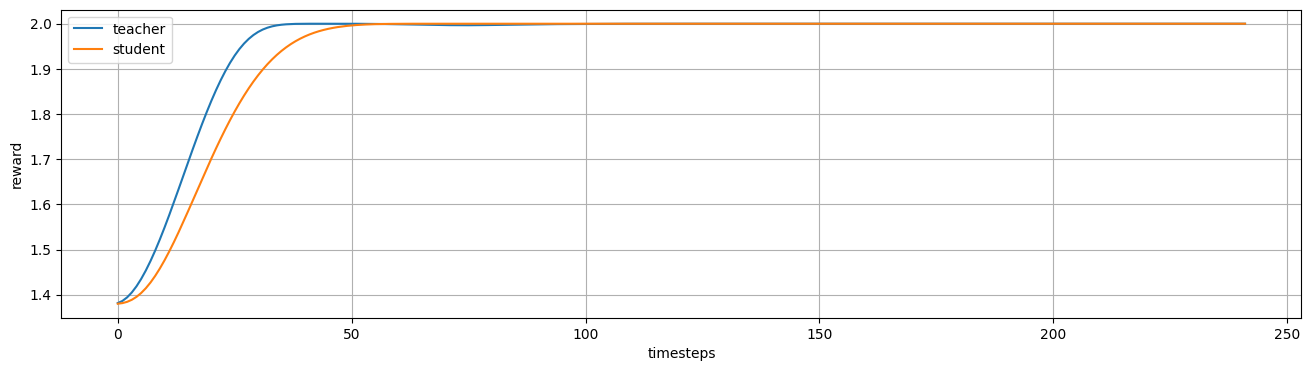

In [10]:
plt.figure(figsize=(16, 4))
plt.plot(teacher_rewards, label = "teacher")
plt.plot(student_rewards, label = "student")
plt.grid()
plt.xlabel("timesteps")
plt.ylabel("reward")
plt.legend()

Text(0.5, 0, 'timesteps')

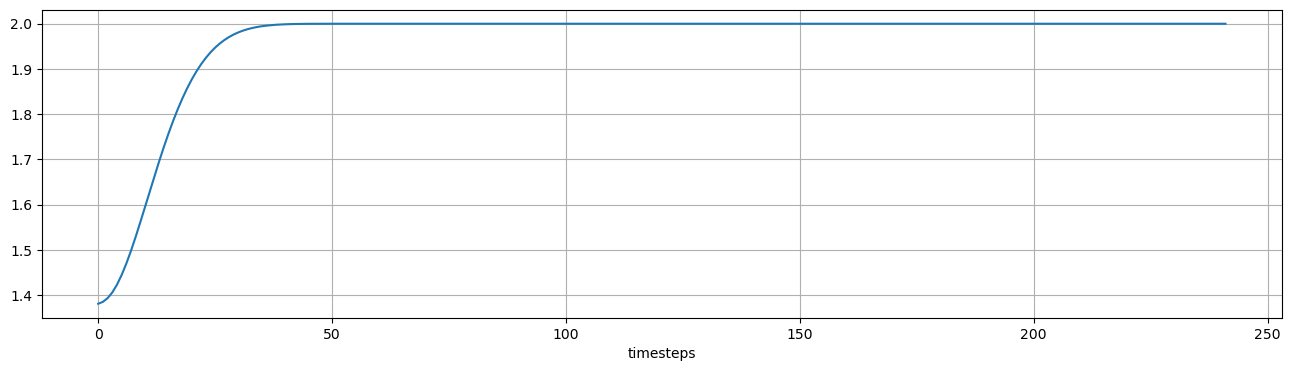

In [ ]:
plt.figure(figsize=(16, 4))

plt.grid()
plt.xlabel("timesteps")

Text(0.5, 0, 'timesteps')

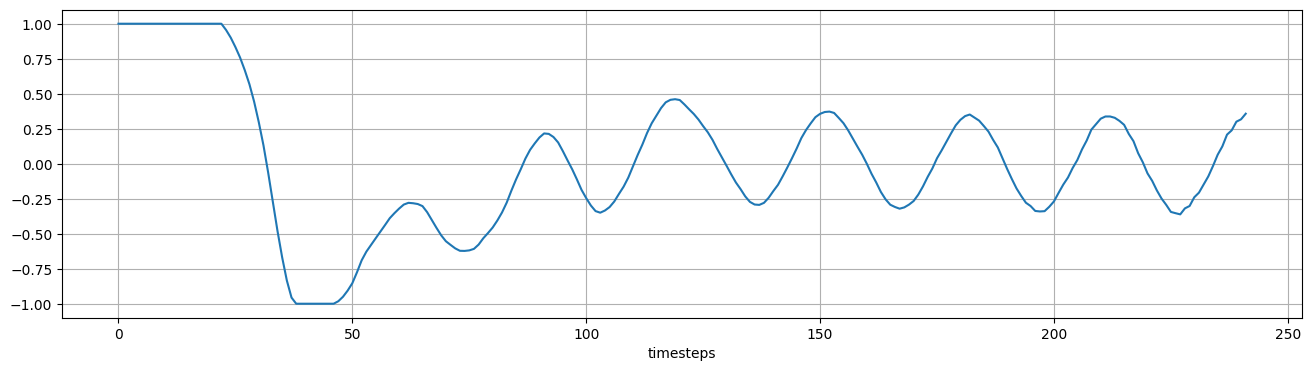

In [8]:
plt.figure(figsize=(16, 4))
plt.plot(teacher_actions)
plt.grid()
plt.xlabel("timesteps")

Text(0.5, 0, 'timesteps')

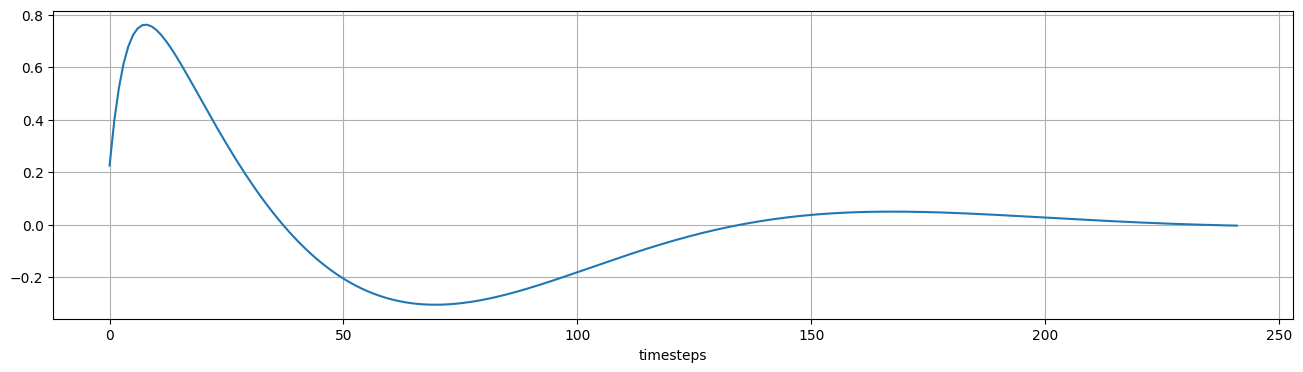

In [9]:
plt.figure(figsize=(16, 4))
plt.plot(student_actions)
plt.grid()
plt.xlabel("timesteps")

In [15]:
import gymnasium as gym
import numpy as np
import pybullet as p
import imageio.v2 as imageio

DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

def record_clean_episode(policy, output_file="hover_clean.mp4", seed=42, max_steps=20,
                         width=1280, height=720, fps=30):
    env = HoverActionShapeWrapper(
        HoverAviary(
            obs=DEFAULT_OBS,
            act=DEFAULT_ACT,
            gui=False,      # no visible GUI window
            record=False,   # do not use built-in recorder
        )
    )

    obs, info = env.reset(seed=seed)
    writer = imageio.get_writer(output_file, fps=fps, codec="libx264")

    try:
        for _ in range(max_steps):
            action, _ = policy.predict(obs, deterministic=True)

            action = np.asarray(action, dtype=np.float32)
            if action.ndim == 2 and action.shape[0] == 1:
                action = action[0]

            obs, reward, terminated, truncated, info = env.step(action)

            # Adjust these camera parameters to taste
            view_matrix = p.computeViewMatrixFromYawPitchRoll(
                cameraTargetPosition=[0, 0, 0.5],
                distance=1.4,
                yaw=45,
                pitch=-30,
                roll=0,
                upAxisIndex=2,
            )

            proj_matrix = p.computeProjectionMatrixFOV(
                fov=60,
                aspect=width / height,
                nearVal=0.1,
                farVal=100.0,
            )

            img = p.getCameraImage(
                width=width,
                height=height,
                viewMatrix=view_matrix,
                projectionMatrix=proj_matrix,
                renderer=p.ER_BULLET_HARDWARE_OPENGL,  # try this first
            )

            rgba = np.reshape(img[2], (height, width, 4))
            rgb = rgba[:, :, :3]
            writer.append_data(rgb)

            if terminated or truncated:
                break
    finally:
        writer.close()
        env.close()

record_clean_episode(student, output_file="hover_clean.mp4", seed=42, max_steps=2000,
                         width=1280, height=720, fps=30)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warni

In [ ]:
student = PySRPolicy.load(r"C:\Users\sofel\OneDrive\Skrivebord\Speciale\safety_addition\GGSpeciale\quadcopter-suite\distil\safety_test\best_student_policy.joblib")
best_policy = student
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.get_best()["equation"]
    print("\nBest equation:")
    print(best_eq)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\GitHub\\GGSpeciale\\quadcopter-suite\\distil-results_1000x12_no_Q\\best_student_policy.joblib'

In [28]:
student = PySRPolicy.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12_no_Q\best_student_policy.joblib")
best_policy = student
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.latex()
    print(best_eq)

Policy loaded

=== Action dimension 0 ===
x_{26} + \left(x_{2} \left(-0.338\right) - \left(x_{19} + x_{8}\right) 0.287\right) 0.427 - 0.241 + 0.378


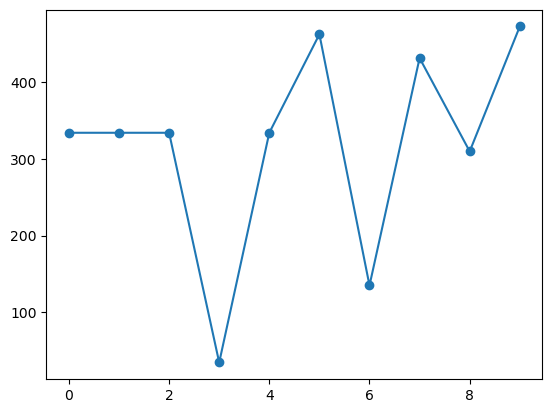

In [35]:
import matplotlib.pyplot as plt

plt.plot(range(len(rewards)), rewards)
plt.scatter(range(len(rewards)), rewards)